Categorico

In [235]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [236]:

ruta = "PROMISE-relabeled-NICE.csv"
df = pd.read_csv(ruta)



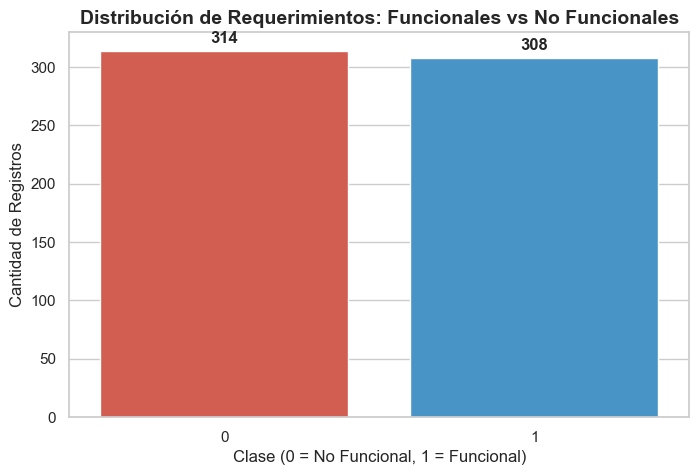

In [237]:
# 2. Configuración visual del diagrama
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='IsFunctional', data=df, palette=['#e74c3c', '#3498db'])

# 3. Personalización del gráfico
plt.title('Distribución de Requerimientos: Funcionales vs No Funcionales', fontsize=14, fontweight='bold')
plt.xlabel('Clase (0 = No Funcional, 1 = Funcional)', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)

# Añadir etiquetas de conteo sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontweight='bold')

plt.show()

In [238]:
features = [
    'Availability (A)', 'Fault Tolerance (FT)', 'Legal (L)', 
    'Look & Feel (LF)', 'Maintainability (MN)', 'Operability (O)', 
    'Performance (PE)', 'Portability (PO)', 'Scalability (SC)', 
    'Security (SE)', 'Usability (US)'
]
target = 'IsFunctional'

In [239]:
print(f"{BOLD}1. Información General del Dataset:{END}")
print(f"Total de registros: {df.shape[0]}")
print(f"Total de columnas iniciales: {df.shape[1]}")
print(f"Valores nulos en el dataset: {df.isnull().sum().sum()} \n")


1. Información General del Dataset:
Total de registros: 622
Total de columnas iniciales: 16
Valores nulos en el dataset: 0 



In [240]:
# Convertir características y target a tipo categoría
for col in features + [target]:
    df[col] = df[col].astype('category')

# %%
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 622 entries, 0 to 621
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   ProjectID             622 non-null    int64   
 1   RequirementText       622 non-null    str     
 2   IsFunctional          622 non-null    category
 3   IsQuality             622 non-null    int64   
 4   Availability (A)      622 non-null    category
 5   Fault Tolerance (FT)  622 non-null    category
 6   Legal (L)             622 non-null    category
 7   Look & Feel (LF)      622 non-null    category
 8   Maintainability (MN)  622 non-null    category
 9   Operability (O)       622 non-null    category
 10  Performance (PE)      622 non-null    category
 11  Portability (PO)      622 non-null    category
 12  Scalability (SC)      622 non-null    category
 13  Security (SE)         622 non-null    category
 14  Usability (US)        622 non-null    category
 15  Other (OT)       

In [241]:
# 4. Análisis de la Variable Objetivo
print(f"{BOLD}{CYAN}2. Distribución de la Variable Objetivo (IsFunctional):{END}")
conteo_target = df[target].value_counts()
porcentaje_target = df[target].value_counts(normalize=True) * 100

tabla_target = pd.DataFrame({
    'Conteo': conteo_target, 
    'Porcentaje (%)': porcentaje_target.round(2)
})
print(tabla_target)
print("\n*Nota: Existe un desbalance de clases (las muestras funcionales y no funcionales no son 50/50). Esto justifica la aplicación de técnicas de remuestreo (SMOTE) en fases posteriores.*\n")

2. Distribución de la Variable Objetivo (IsFunctional):
              Conteo  Porcentaje (%)
IsFunctional                        
0                314           50.48
1                308           49.52

*Nota: Existe un desbalance de clases (las muestras funcionales y no funcionales no son 50/50). Esto justifica la aplicación de técnicas de remuestreo (SMOTE) en fases posteriores.*



In [242]:
# 5. Análisis del Texto (Longitud de los Requerimientos)
df['Text_Length'] = df['RequirementText'].apply(lambda x: len(str(x).split()))
print(f"{BOLD}{CYAN}3. Estadísticas de longitud de texto (palabras):{END}")
print(df['Text_Length'].describe().round(2))

3. Estadísticas de longitud de texto (palabras):
count    622.00
mean      19.59
std       10.11
min        6.00
25%       13.00
50%       17.00
75%       23.75
max       84.00
Name: Text_Length, dtype: float64


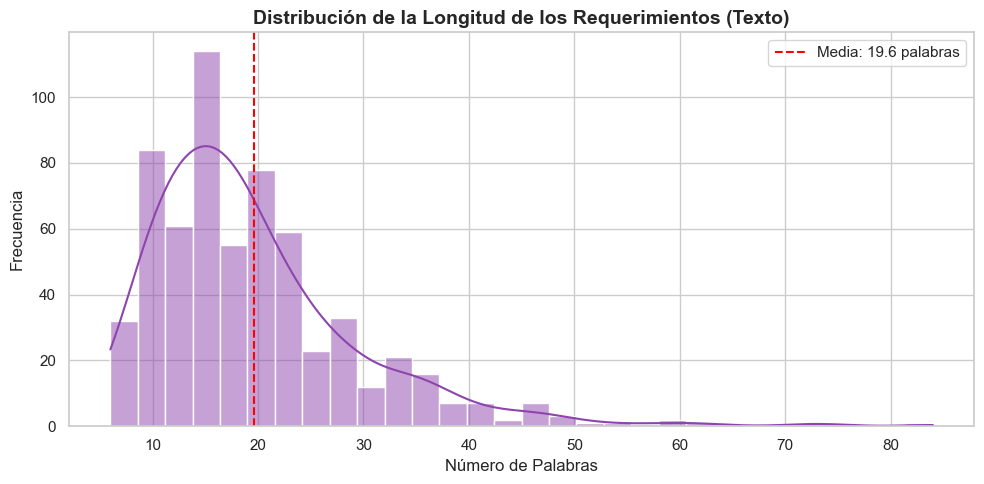

In [243]:
# ==========================================
# VISUALIZACIONES ESTADÍSTICAS
# ==========================================
sns.set_theme(style="whitegrid")

# Figura 1: Distribución de la Longitud del Texto
plt.figure(figsize=(10, 5))
sns.histplot(df['Text_Length'], bins=30, kde=True, color='#8E44AD')
plt.axvline(df['Text_Length'].mean(), color='red', linestyle='--', label=f"Media: {df['Text_Length'].mean():.1f} palabras")
plt.title('Distribución de la Longitud de los Requerimientos (Texto)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Palabras', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

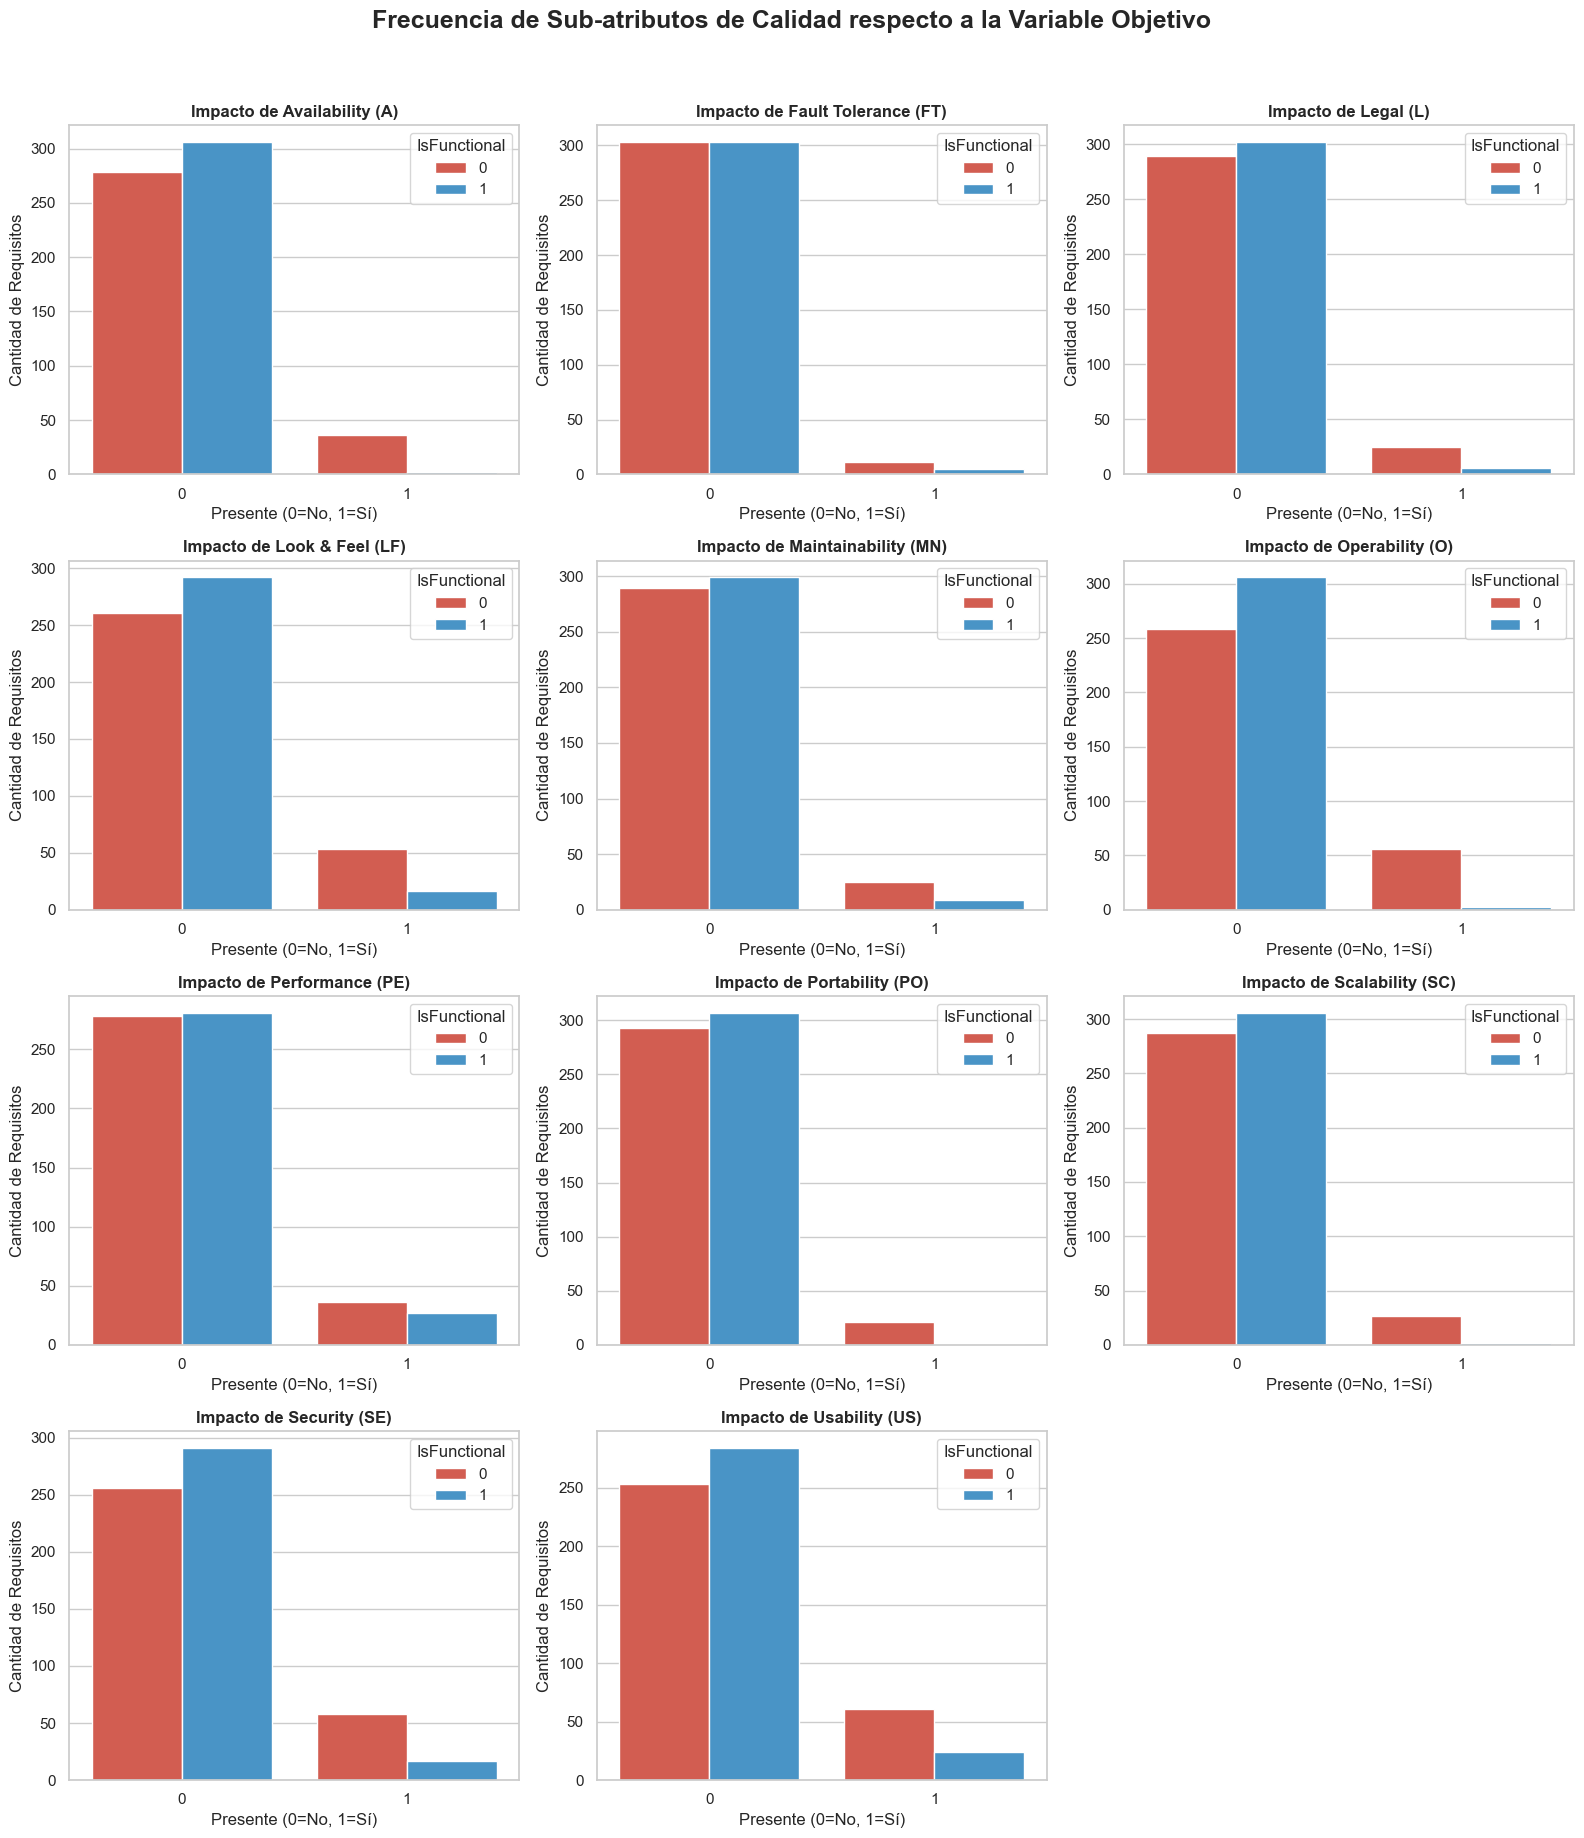

In [244]:
num_features = len(features)
cols = 3
rows = (num_features // cols) + (1 if num_features % cols > 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(16, 18))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.countplot(
        data=df, 
        x=feature, 
        hue=target, 
        palette={0: '#e74c3c', 1: '#3498db'}, # Rojo = No Funcional, Azul = Funcional
        ax=axes[i]
    )
    axes[i].set_title(f'Impacto de {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Presente (0=No, 1=Sí)')
    axes[i].set_ylabel('Cantidad de Requisitos')
    axes[i].legend(title='IsFunctional', loc='upper right')

# Ocultar el último recuadro vacío (porque son 11 gráficas y la cuadrícula es de 12)
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Frecuencia de Sub-atributos de Calidad respecto a la Variable Objetivo', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [245]:
# Variables iniciales
X_text = df['RequirementText']
X_cat = df[features] 
y = df['IsFunctional']

In [246]:
X_train_text, X_test_text, X_train_cat, X_test_cat, y_train, y_test = train_test_split(
    X_text, X_cat, y, test_size=0.30, stratify=y, random_state=42
)

In [247]:
# Resetear índices para evitar errores al concatenar más adelante
X_train_cat = X_train_cat.reset_index(drop=True)
X_test_cat = X_test_cat.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


In [248]:
X_train_text

241    'The vehicle location shall include street add...
175    'The Disputes application must maintain a deta...
516    'The product shall prevent the player from ove...
603    'The application shall be able to complete eve...
392    'The product shall be easy for customers with ...
                             ...                        
242    'The system shall resolve the zipcode for the ...
187    'The Disputes System must prevent external use...
38     'The product shall generate a CMA report in an...
20     'The system shall allow modification of the di...
84     'The system shall able to operate within a bus...
Name: RequirementText, Length: 435, dtype: str

In [249]:
X_train_cat

,Availability (A),Fault Tolerance (FT),Legal (L),Look & Feel (LF),Maintainability (MN),Operability (O),Performance (PE),Portability (PO),Scalability (SC),Security (SE),Usability (US)
0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
430,0,0,0,0,0,0,0,0,0,0,0
431,0,0,0,0,0,0,0,0,0,0,0
432,0,0,0,0,0,0,1,0,0,0,0
433,0,0,0,0,0,0,0,0,0,0,0


## Fase B

In [250]:
# 3. Limpieza de Texto Básica

In [251]:
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import warnings

In [252]:
def limpiar_texto(texto):
    """
    Limpia el texto convirtiendo a minúsculas, eliminando caracteres no alfabéticos
    y removiendo palabras comunes (stop words).
    """
    texto = str(texto).lower() # Convertir a minúsculas
    texto = re.sub(r'[^a-z\s]', '', texto) # Eliminar signos y números
    palabras = [p for p in texto.split() if p not in ENGLISH_STOP_WORDS]
    return ' '.join(palabras)

In [253]:
print(f"{BOLD}Limpiando y vectorizando el texto con TF-IDF...{END}")
X_train_text_clean = X_train_text.apply(limpiar_texto)
X_test_text_clean = X_test_text.apply(limpiar_texto)

tfidf = TfidfVectorizer(max_features=300) 
X_train_tfidf = pd.DataFrame(tfidf.fit_transform(X_train_text_clean).toarray(), columns=tfidf.get_feature_names_out())
X_test_tfidf = pd.DataFrame(tfidf.transform(X_test_text_clean).toarray(), columns=tfidf.get_feature_names_out())

# 5. FUSIÓN: Texto (TF-IDF) + Variables Categóricas
# Mantenemos el nombre 'X_train_bal' por compatibilidad con los bloques siguientes
X_train_bal = pd.concat([X_train_tfidf, X_train_cat], axis=1)
X_test_final = pd.concat([X_test_tfidf, X_test_cat], axis=1)
y_train_bal = y_train 

print(f"-> Dimensiones de Entrenamiento: {X_train_bal.shape}")
print(f"-> Dimensiones de Pruebas: {X_test_final.shape}\n")
print(f"{BOLD}¡Preprocesamiento completado con éxito!{END}")

Limpiando y vectorizando el texto con TF-IDF...
-> Dimensiones de Entrenamiento: (435, 311)
-> Dimensiones de Pruebas: (187, 311)

¡Preprocesamiento completado con éxito!


In [254]:
# %% [markdown]
# ### Fase C: Selección de Características
# En esta fase aplicaremos dos estrategias para reducir la dimensionalidad y quedarnos solo con los predictores más valiosos:
# 1. **Filtro por Árbol de Decisión:** Identificamos las variables que el árbol usó para hacer divisiones (importancia > 0).
# 2. **Filtro por Información Mutua:** Seleccionamos las 50 características con mayor dependencia estadística respecto a la variable objetivo.

# %%
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier

print(f"{BOLD}{CYAN}=== FASE C: SELECCIÓN DE CARACTERÍSTICAS ==={END}\n")

# --- ESTRATEGIA 1: Importancia por Árbol de Decisión ---
print("Ejecutando Árbol de Decisión preliminar para identificar variables clave...")
dt_selector = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_selector.fit(X_train_bal, y_train_bal)

# Extraer nombres de columnas que el árbol consideró útiles
dt_features = X_train_bal.columns[dt_selector.feature_importances_ > 0].tolist()

# Crear los subsets filtrados por el Árbol
X_train_dt = X_train_bal[dt_features]
X_test_dt = X_test_final[dt_features]

print(f"   -> El Árbol seleccionó {len(dt_features)} características relevantes.")

# --- ESTRATEGIA 2: Información Mutua (MI) ---
print("\nCalculando relevancia por Información Mutua...")
mi_scores = mutual_info_classif(X_train_bal, y_train_bal, random_state=42)
mi_ranking = pd.Series(mi_scores, index=X_train_bal.columns).sort_values(ascending=False)

# Seleccionamos el Top 50
mi_features = mi_ranking.head(50).index.tolist()

# Crear los subsets filtrados por MI
X_train_mi = X_train_bal[mi_features]
X_test_mi = X_test_final[mi_features]

print(f"   -> Se seleccionaron las {len(mi_features)} mejores características mediante MI.")

# --- VISUALIZACIÓN DEL RANKING ---
print(f"\n{BOLD}Top 10 Características (Ranking Info Mutua):{END}")
print(mi_ranking.head(10).round(4))

=== FASE C: SELECCIÓN DE CARACTERÍSTICAS ===

Ejecutando Árbol de Decisión preliminar para identificar variables clave...
   -> El Árbol seleccionó 49 características relevantes.

Calculando relevancia por Información Mutua...
   -> Se seleccionaron las 50 mejores características mediante MI.

Top 10 Características (Ranking Info Mutua):
include             0.0696
record              0.0676
transaction         0.0644
recycled            0.0597
services            0.0589
Portability (PO)    0.0561
repair              0.0560
external            0.0537
market              0.0530
update              0.0523
dtype: float64


=== ANÁLISIS DE IMPORTANCIA DEL ÁRBOL ===



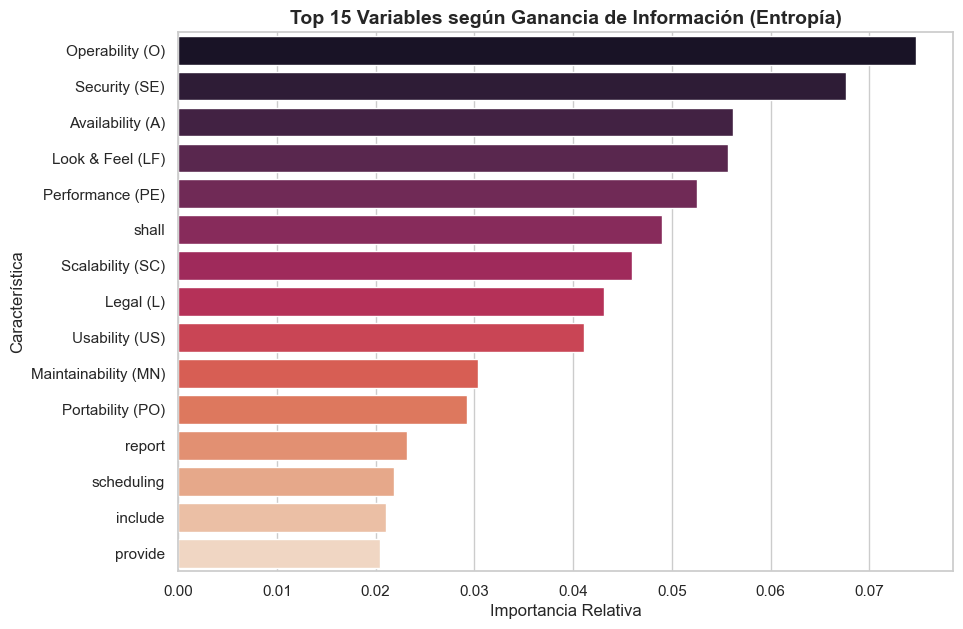

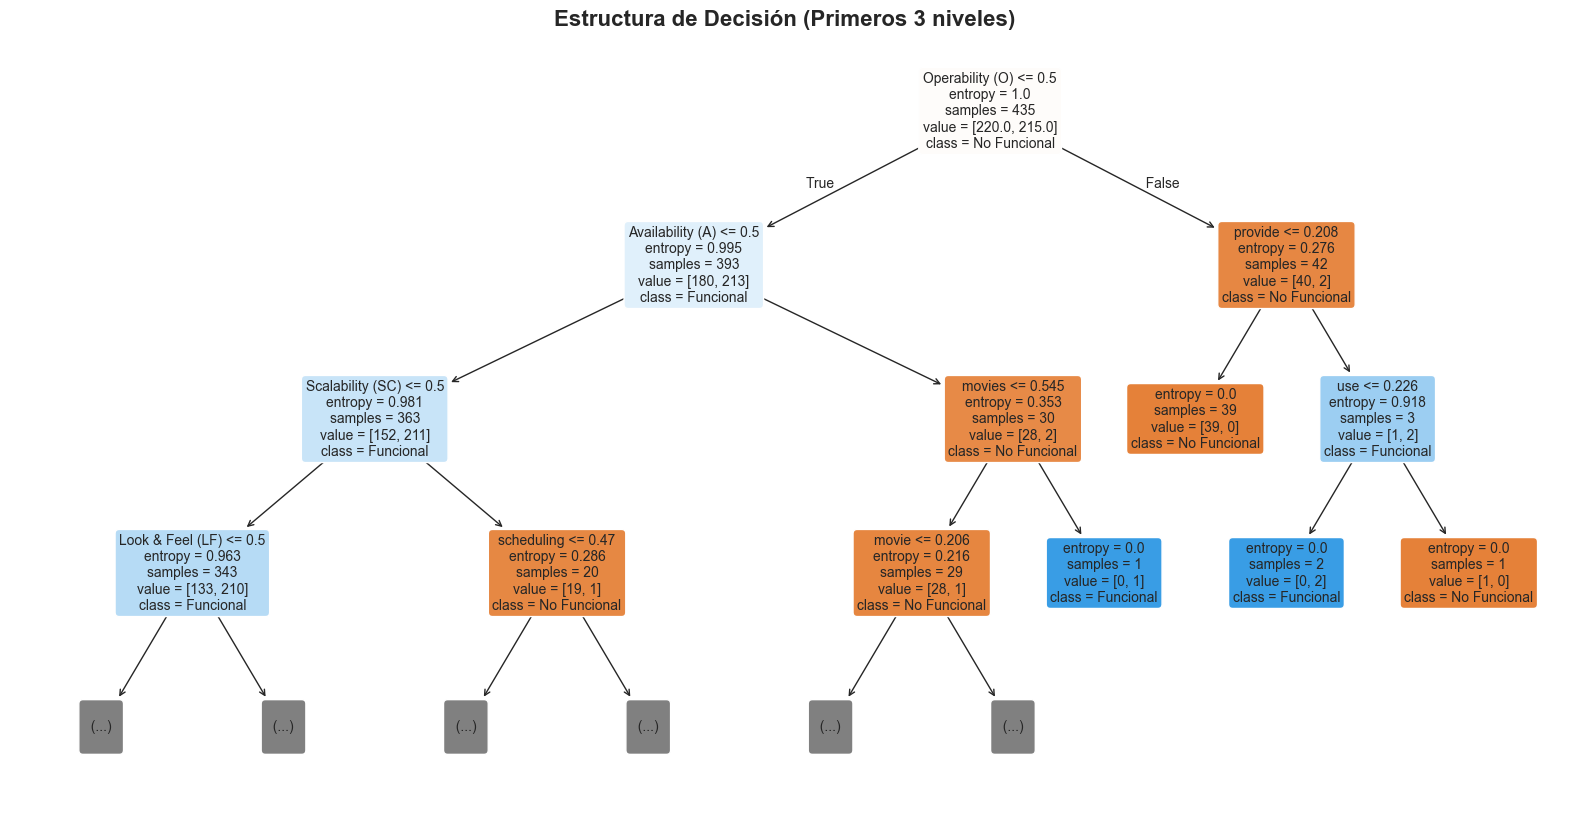

El árbol descartó 262 variables por tener importancia cero.


In [255]:
# %% [markdown]
# ### Fase C (Continuación): Análisis de Importancia del Árbol de Decisión
# El Árbol de Decisión selecciona variables basándose en la **Ganancia de Información** (reducción de Entropía). 
# Visualizaremos cuáles fueron las variables con mayor peso y la estructura de decisión inicial.

# %%
from sklearn.tree import plot_tree

print(f"{BOLD}{CYAN}=== ANÁLISIS DE IMPORTANCIA DEL ÁRBOL ==={END}\n")

# 1. Extraer importancias y filtrar las que son mayores a cero
df_importancias = pd.DataFrame({
    'Característica': X_train_bal.columns,
    'Importancia': dt_selector.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Solo nos interesan las variables que el árbol REALMENTE usó
df_importancias_utiles = df_importancias[df_importancias['Importancia'] > 0]

# 2. Visualización: Ranking de Importancia del Árbol
plt.figure(figsize=(10, 7))
sns.barplot(
    data=df_importancias_utiles.head(15), 
    x='Importancia', 
    y='Característica', 
    palette='rocket'
)
plt.title('Top 15 Variables según Ganancia de Información (Entropía)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia Relativa', fontsize=12)
plt.show()

# 3. Visualización: Estructura del Árbol (Niveles Superiores)
plt.figure(figsize=(20, 10))
plot_tree(
    dt_selector, 
    max_depth=3,                   
    feature_names=X_train_bal.columns.tolist(), # .tolist() para evitar advertencias de sklearn
    class_names=['No Funcional', 'Funcional'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title('Estructura de Decisión (Primeros 3 niveles)', fontsize=16, fontweight='bold')
plt.show()

print(f"El árbol descartó {len(df_importancias) - len(df_importancias_utiles)} variables por tener importancia cero.")

=== FASE C: SELECCIÓN DE CARACTERÍSTICAS ===

Calculando relevancia estadística de todas las variables...


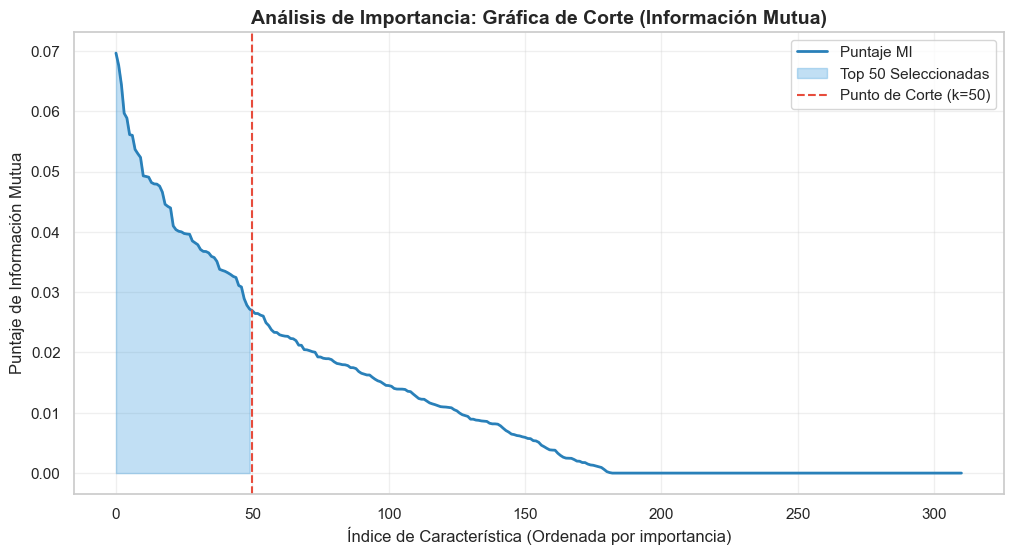

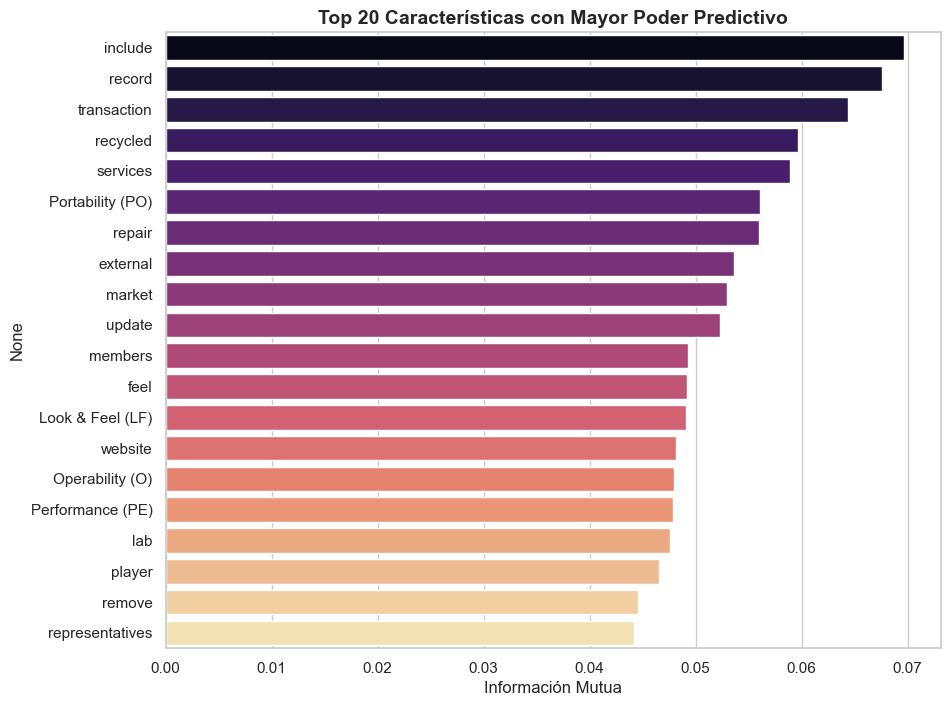


Justificación del Corte:
Se seleccionaron 50 variables porque después de este punto, la ganancia de información decae significativamente (punto de codo).


In [256]:
# %% [markdown]
# ### Fase C: Selección de Características y Análisis de Corte
# En esta sección justificaremos visualmente la selección de las 50 mejores características mediante un análisis de la distribución de los puntajes de Información Mutua.

# %%
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(f"{BOLD}{CYAN}=== FASE C: SELECCIÓN DE CARACTERÍSTICAS ==={END}\n")

# 1. Calcular Información Mutua (MI)
print("Calculando relevancia estadística de todas las variables...")
mi_scores = mutual_info_classif(X_train_bal, y_train_bal, random_state=42)
mi_ranking = pd.Series(mi_scores, index=X_train_bal.columns).sort_values(ascending=False)

# 2. Definir el punto de corte
n_corte = 50 
mi_features = mi_ranking.head(n_corte).index.tolist()

# --- VISUALIZACIÓN 1: Gráfica de Corte (Scree Plot) ---
plt.figure(figsize=(12, 6))

# Dibujamos todos los puntajes
plt.plot(range(len(mi_ranking)), mi_ranking.values, color='#2980b9', linewidth=2, label='Puntaje MI')

# Resaltamos el área de las seleccionadas
plt.fill_between(range(n_corte), mi_ranking.values[:n_corte], color='#3498db', alpha=0.3, label='Top 50 Seleccionadas')

# Línea vertical de corte
plt.axvline(x=n_corte, color='#e74c3c', linestyle='--', label=f'Punto de Corte (k={n_corte})')

plt.title('Análisis de Importancia: Gráfica de Corte (Información Mutua)', fontsize=14, fontweight='bold')
plt.xlabel('Índice de Característica (Ordenada por importancia)', fontsize=12)
plt.ylabel('Puntaje de Información Mutua', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- VISUALIZACIÓN 2: Zoom al Top 20 ---
plt.figure(figsize=(10, 8))
top_20 = mi_ranking.head(20)
sns.barplot(x=top_20.values, y=top_20.index, palette='magma')
plt.title('Top 20 Características con Mayor Poder Predictivo', fontsize=14, fontweight='bold')
plt.xlabel('Información Mutua', fontsize=12)
plt.show()

# 3. Preparar los conjuntos de datos filtrados
X_train_mi = X_train_bal[mi_features]
X_test_mi = X_test_final[mi_features]

# Selección por Árbol (para el modelo iii)
dt_selector = DecisionTreeClassifier(criterion='entropy', max_depth=15, random_state=42)
dt_selector.fit(X_train_bal, y_train_bal)
dt_features = X_train_bal.columns[dt_selector.feature_importances_ > 0].tolist()
X_train_dt = X_train_bal[dt_features]
X_test_dt = X_test_final[dt_features]

print(f"\n{BOLD}Justificación del Corte:{END}")
print(f"Se seleccionaron {n_corte} variables porque después de este punto, la ganancia de información decae significativamente (punto de codo).")

In [257]:
# %% [markdown]
# ### Fase D: Aprendizaje y Evaluación de Modelos
# En esta etapa final entrenamos los 4 escenarios solicitados utilizando **Validación Cruzada (10-Fold CV)**.
# Evaluaremos el desempeño con la métrica de **Exactitud (Accuracy)** sobre el conjunto de prueba (30%).

# %%
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

print(f"{BOLD}{BLUE}=== FASE D: EVALUACIÓN DE LOS 4 MODELOS ==={END}\n")

# Configuración de Validación Cruzada
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ---------------------------------------------------------
# i) Árbol de Decisión (Todas las variables)
# ---------------------------------------------------------
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=15, min_samples_leaf=5, random_state=42)
cv_dt = cross_val_score(dt_model, X_train_bal, y_train_bal, cv=cv_strategy)
dt_model.fit(X_train_bal, y_train_bal)
acc_dt = accuracy_score(y_test, dt_model.predict(X_test_final))

print(f"{BOLD}i) Árbol de Decisión (Full Set):{END}")
print(f"   Accuracy CV: {cv_dt.mean():.4f} | Accuracy Test: {acc_dt:.4f}\n")

# ---------------------------------------------------------
# ii) Naive Bayes (Todas las variables)
# ---------------------------------------------------------
nb_all = MultinomialNB(alpha=1.0)
cv_nb_all = cross_val_score(nb_all, X_train_bal, y_train_bal, cv=cv_strategy)
nb_all.fit(X_train_bal, y_train_bal)
acc_nb_all = accuracy_score(y_test, nb_all.predict(X_test_final))

print(f"{BOLD}ii) Naive Bayes (Full Set):{END}")
print(f"   Accuracy CV: {cv_nb_all.mean():.4f} | Accuracy Test: {acc_nb_all:.4f}\n")

# ---------------------------------------------------------
# iii) Naive Bayes (Filtro por Árbol de Decisión)
# ---------------------------------------------------------
# Usamos X_train_dt y X_test_dt creados en la Fase C
nb_dt = MultinomialNB(alpha=1.0)
cv_nb_dt = cross_val_score(nb_dt, X_train_dt, y_train_bal, cv=cv_strategy)
nb_dt.fit(X_train_dt, y_train_bal)
acc_nb_dt = accuracy_score(y_test, nb_dt.predict(X_test_dt))

print(f"{BOLD}iii) Naive Bayes (Filtro Árbol - {len(dt_features)} vars):{END}")
print(f"   Accuracy CV: {cv_nb_dt.mean():.4f} | Accuracy Test: {acc_nb_dt:.4f}\n")

# ---------------------------------------------------------
# iv) Naive Bayes (Filtro por Información Mutua)
# ---------------------------------------------------------
# Usamos X_train_mi y X_test_mi (Top 50) creados en la Fase C
nb_mi = MultinomialNB(alpha=1.0)
cv_nb_mi = cross_val_score(nb_mi, X_train_mi, y_train_bal, cv=cv_strategy)
nb_mi.fit(X_train_mi, y_train_bal)
acc_nb_mi = accuracy_score(y_test, nb_mi.predict(X_test_mi))

print(f"{BOLD}iv) Naive Bayes (Filtro MI - Top 50):{END}")
print(f"   Accuracy CV: {cv_nb_mi.mean():.4f} | Accuracy Test: {acc_nb_mi:.4f}\n")

# ---------------------------------------------------------
# REPORTE FINAL DEL GANADOR
# ---------------------------------------------------------
res = {"Árbol": acc_dt, "NB Todas": acc_nb_all, "NB Árbol": acc_nb_dt, "NB MI": acc_nb_mi}
ganador = max(res, key=res.get)

print(f"{BOLD}{BLUE}=== CONCLUSIÓN FINAL ==={END}")
print(f"El mejor modelo es: {BOLD}{ganador}{END} con {res[ganador]:.4f} de Accuracy.")

# Mostramos el reporte detallado del ganador (ejemplo con Naive Bayes Todas si es el mejor)
y_pred_final = nb_all.predict(X_test_final) if ganador != "Árbol" else dt_model.predict(X_test_final)
print("\nReporte Detallado:")
print(classification_report(y_test, y_pred_final, target_names=['No Funcional', 'Funcional']))

=== FASE D: EVALUACIÓN DE LOS 4 MODELOS ===

i) Árbol de Decisión (Full Set):
   Accuracy CV: 0.7884 | Accuracy Test: 0.8182

ii) Naive Bayes (Full Set):
   Accuracy CV: 0.8343 | Accuracy Test: 0.8449

iii) Naive Bayes (Filtro Árbol - 45 vars):
   Accuracy CV: 0.8529 | Accuracy Test: 0.7968

iv) Naive Bayes (Filtro MI - Top 50):
   Accuracy CV: 0.7147 | Accuracy Test: 0.6684

=== CONCLUSIÓN FINAL ===
El mejor modelo es: NB Todas con 0.8449 de Accuracy.

Reporte Detallado:
              precision    recall  f1-score   support

No Funcional       0.84      0.85      0.85        94
   Funcional       0.85      0.84      0.84        93

    accuracy                           0.84       187
   macro avg       0.84      0.84      0.84       187
weighted avg       0.84      0.84      0.84       187



=== INICIANDO EXPERIMENTO: 10 ITERACIONES / TODAS LAS MÉTRICAS (TRAIN & TEST) ===

DETALLE POR ITERACIÓN (Completo):

 Iter       Modelo Tr_Acc Tr_Pre Tr_Rec Tr_Esp  Tr_F1 Tr_MCC Te_Acc Te_Pre Te_Rec Te_Esp  Te_F1 Te_MCC
    1        Árbol 0.9839 0.9727 0.9953 0.9727 0.9839 0.9681 0.8021 0.8333 0.7527 0.8511 0.7910 0.6069
    1     NB_Todas 0.8851 0.9188 0.8419 0.9273 0.8786 0.7725 0.8556 0.9125 0.7849 0.9255 0.8439 0.7180
    1 NB_Filtro_DT 0.8368 0.8103 0.8744 0.8000 0.8412 0.6759 0.7807 0.7708 0.7957 0.7660 0.7831 0.5618
    1 NB_Filtro_MI 0.6989 0.7727 0.5535 0.8409 0.6450 0.4123 0.6791 0.7619 0.5161 0.8404 0.6154 0.3772
    2        Árbol 0.9931 0.9862 1.0000 0.9864 0.9931 0.9863 0.8235 0.8261 0.8172 0.8298 0.8216 0.6471
    2     NB_Todas 0.8943 0.9424 0.8372 0.9500 0.8867 0.7931 0.8556 0.8929 0.8065 0.9043 0.8475 0.7144
    2 NB_Filtro_DT 0.8391 0.8222 0.8605 0.8182 0.8409 0.6790 0.8075 0.8000 0.8172 0.7979 0.8085 0.6151
    2 NB_Filtro_MI 0.7471 0.8431 0.6000 0.8909 0.7011 0.51

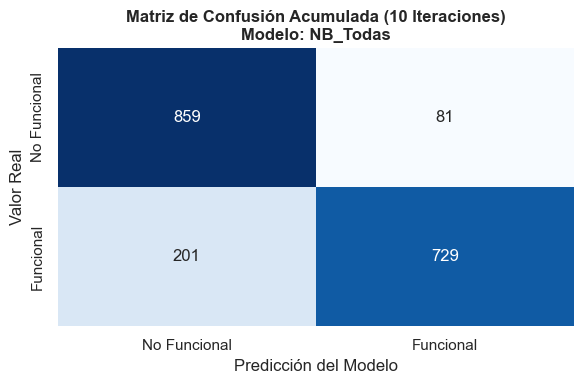

In [258]:
# %% [markdown]
# ### Fase E: Reporte Multimétrica Detallado y Matriz de Confusión
# Evaluación de modelos con 10 iteraciones. Incluye Accuracy, Precision, Recall, Specificity, 
# F1-Score y MCC agrupando métricas de TRAIN primero y TEST después. Resultados transpuestos.

# %%
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, matthews_corrcoef
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=== INICIANDO EXPERIMENTO: 10 ITERACIONES / TODAS LAS MÉTRICAS (TRAIN & TEST) ===\n")

log_completo = []

# Diccionario expandido para incluir métricas de Train y Test
metricas = ['tr_acc', 'te_acc', 'tr_pre', 'te_pre', 'tr_rec', 'te_rec', 'tr_esp', 'te_esp', 'tr_f1', 'te_f1', 'tr_mcc', 'te_mcc']
stats_global = {m: {met: [] for met in metricas} for m in ["Árbol", "NB_Todas", "NB_Filtro_DT", "NB_Filtro_MI"]}

matrices_confusion = {m: np.zeros((2, 2)) for m in ["Árbol", "NB_Todas", "NB_Filtro_DT", "NB_Filtro_MI"]}

for i in range(1, 11):
    X_tr_t, X_te_t, X_tr_c, X_te_c, y_tr_raw, y_te_raw = train_test_split(
        X_text, X_cat, y, test_size=0.30, stratify=y, random_state=i*123
    )
    
    tfidf_it = TfidfVectorizer(max_features=300)
    X_tr_tfidf = pd.DataFrame(tfidf_it.fit_transform(X_tr_t.apply(limpiar_texto)).toarray(), 
                              columns=tfidf_it.get_feature_names_out())
    X_te_tfidf = pd.DataFrame(tfidf_it.transform(X_te_t.apply(limpiar_texto)).toarray(), 
                              columns=tfidf_it.get_feature_names_out())
    
    X_tr = pd.concat([X_tr_tfidf, X_tr_c.reset_index(drop=True)], axis=1)
    X_te = pd.concat([X_te_tfidf, X_te_c.reset_index(drop=True)], axis=1)
    y_tr, y_te = y_tr_raw.reset_index(drop=True), y_te_raw.reset_index(drop=True)
    
    dt_sel = DecisionTreeClassifier(criterion='entropy', max_depth=15, random_state=42).fit(X_tr, y_tr)
    f_dt = X_tr.columns[dt_sel.feature_importances_ > 0].tolist()
    mi_s = mutual_info_classif(X_tr, y_tr, random_state=42)
    f_mi = pd.Series(mi_s, index=X_tr.columns).sort_values(ascending=False).head(50).index.tolist()

    modelos = {
        "Árbol": (DecisionTreeClassifier(criterion='entropy', max_depth=15), X_tr, X_te),
        "NB_Todas": (MultinomialNB(), X_tr, X_te),
        "NB_Filtro_DT": (MultinomialNB(), X_tr[f_dt], X_te[f_dt]),
        "NB_Filtro_MI": (MultinomialNB(), X_tr[f_mi], X_te[f_mi])
    }

    for nombre, (clf, train_set, test_set) in modelos.items():
        clf.fit(train_set, y_tr)
        
        y_tr_pred = clf.predict(train_set)
        y_te_pred = clf.predict(test_set)
        
        # Matriz de confusión Test (Acumulada y para métricas)
        cm_te = confusion_matrix(y_te, y_te_pred)
        matrices_confusion[nombre] += cm_te
        tn_te, fp_te, fn_te, tp_te = cm_te.ravel()
        
        # Matriz de confusión Train (Para especificidad)
        cm_tr = confusion_matrix(y_tr, y_tr_pred)
        tn_tr, fp_tr, fn_tr, tp_tr = cm_tr.ravel()
        
        # Cálculo de Métricas TRAIN
        tr_acc = accuracy_score(y_tr, y_tr_pred)
        tr_pre = precision_score(y_tr, y_tr_pred, zero_division=0)
        tr_rec = recall_score(y_tr, y_tr_pred, zero_division=0)
        tr_esp = tn_tr / (tn_tr + fp_tr) if (tn_tr + fp_tr) > 0 else 0
        tr_f1  = f1_score(y_tr, y_tr_pred, zero_division=0)
        tr_mcc = matthews_corrcoef(y_tr, y_tr_pred)

        # Cálculo de Métricas TEST
        te_acc = accuracy_score(y_te, y_te_pred)
        te_pre = precision_score(y_te, y_te_pred, zero_division=0)
        te_rec = recall_score(y_te, y_te_pred, zero_division=0)
        te_esp = tn_te / (tn_te + fp_te) if (tn_te + fp_te) > 0 else 0
        te_f1  = f1_score(y_te, y_te_pred, zero_division=0)
        te_mcc = matthews_corrcoef(y_te, y_te_pred)
        
        # Guardado en log agrupado: Primero Train, luego Test
        log_completo.append([i, nombre, tr_acc, tr_pre, tr_rec, tr_esp, tr_f1, tr_mcc, te_acc, te_pre, te_rec, te_esp, te_f1, te_mcc])
        
        # Guardar en diccionario
        stats_global[nombre]['tr_acc'].append(tr_acc)
        stats_global[nombre]['te_acc'].append(te_acc)
        stats_global[nombre]['tr_pre'].append(tr_pre)
        stats_global[nombre]['te_pre'].append(te_pre)
        stats_global[nombre]['tr_rec'].append(tr_rec)
        stats_global[nombre]['te_rec'].append(te_rec)
        stats_global[nombre]['tr_esp'].append(tr_esp)
        stats_global[nombre]['te_esp'].append(te_esp)
        stats_global[nombre]['tr_f1'].append(tr_f1)
        stats_global[nombre]['te_f1'].append(te_f1)
        stats_global[nombre]['tr_mcc'].append(tr_mcc)
        stats_global[nombre]['te_mcc'].append(te_mcc)

# %%
# Visualización del Log Detallado Completo
columnas_log = ['Iter', 'Modelo', 'Tr_Acc', 'Tr_Pre', 'Tr_Rec', 'Tr_Esp', 'Tr_F1', 'Tr_MCC', 'Te_Acc', 'Te_Pre', 'Te_Rec', 'Te_Esp', 'Te_F1', 'Te_MCC']
df_log = pd.DataFrame(log_completo, columns=columnas_log)
pd.set_option('display.max_rows', 50) 
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', 1000)
print("DETALLE POR ITERACIÓN (Completo):\n")
print(df_log.to_string(index=False, formatters={f: '{:.4f}'.format for f in df_log.columns if f not in ['Iter', 'Modelo']}))

# %%
# Resumen Final de Promedios (Agrupado)
res_promedio = []
for m, s in stats_global.items():
    res_promedio.append({
        "Modelo": m,
        "Train_Acc": np.mean(s['tr_acc']),
        "Train_Prec": np.mean(s['tr_pre']),
        "Train_Rec": np.mean(s['tr_rec']),
        "Train_Esp": np.mean(s['tr_esp']),
        "Train_F1": np.mean(s['tr_f1']),
        "Train_MCC": np.mean(s['tr_mcc']),
        "Test_Acc": np.mean(s['te_acc']),
        "Test_Prec": np.mean(s['te_pre']),
        "Test_Rec": np.mean(s['te_rec']),
        "Test_Esp": np.mean(s['te_esp']),
        "Test_F1": np.mean(s['te_f1']),
        "Test_MCC": np.mean(s['te_mcc'])
    })

# Convertimos a DataFrame, ordenamos por el Test_MCC (mejor rendimiento general) y transponemos
df_res_final = pd.DataFrame(res_promedio).sort_values(by="Test_MCC", ascending=False)
df_transpuesto = df_res_final.set_index('Modelo').T

print("\n=== RESUMEN FINAL PROMEDIO (10 VUELTAS) ===\n")
print(df_transpuesto.to_string(float_format=lambda x: '{:.4f}'.format(x)))

# %%
# Visualización de la Matriz de Confusión Acumulada del Mejor Modelo
mejor_modelo = df_res_final.iloc[0]['Modelo']
cm_mejor = matrices_confusion[mejor_modelo]

plt.figure(figsize=(6, 4))
sns.heatmap(cm_mejor, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=['No Funcional', 'Funcional'], 
            yticklabels=['No Funcional', 'Funcional'])
plt.title(f'Matriz de Confusión Acumulada (10 Iteraciones)\nModelo: {mejor_modelo}', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

=== GENERANDO GRÁFICA DE DIAGNÓSTICO DE SOBREAJUSTE ===



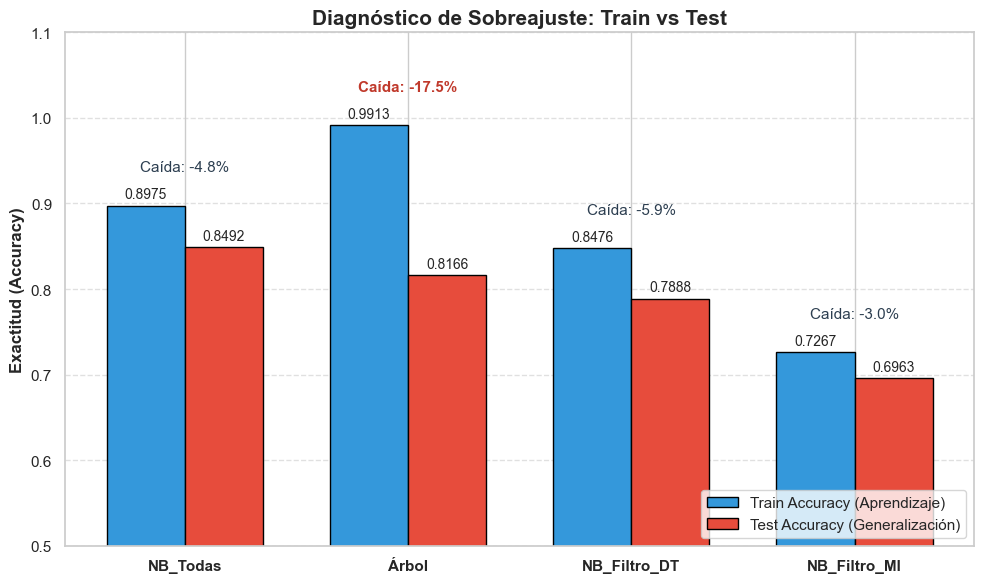

In [259]:
# %% [markdown]
# ### Visualización de Sobreajuste (Train vs Test)
# Gráfico de barras para comparar el rendimiento de aprendizaje (Train) frente a la 
# generalización (Test). Las brechas grandes indican sobreajuste (memorización).

# %%
import matplotlib.pyplot as plt
import numpy as np

print("=== GENERANDO GRÁFICA DE DIAGNÓSTICO DE SOBREAJUSTE ===\n")

# Datos extraídos del resumen final
modelos = ['NB_Todas', 'Árbol', 'NB_Filtro_DT', 'NB_Filtro_MI']
train_acc = [0.8975, 0.9913, 0.8476, 0.7267]
test_acc = [0.8492, 0.8166, 0.7888, 0.6963]

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Creación de las barras
rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy (Aprendizaje)', color='#3498db', edgecolor='black')
rects2 = ax.bar(x + width/2, test_acc, width, label='Test Accuracy (Generalización)', color='#e74c3c', edgecolor='black')

# Personalización
ax.set_ylabel('Exactitud (Accuracy)', fontsize=12, fontweight='bold')
ax.set_title('Diagnóstico de Sobreajuste: Train vs Test', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_ylim(0.5, 1.1) # Rango en Y ajustado para dar espacio a las etiquetas

# Función para poner los números encima de las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

# Añadir la "brecha" de caída porcentual para evidenciar el sobreajuste
for i in range(len(modelos)):
    brecha = (train_acc[i] - test_acc[i]) * 100
    # Si la brecha es mayor al 10%, la pintamos de rojo intenso para señalar peligro
    color_texto = '#c0392b' if brecha > 10 else '#2c3e50'
    peso = 'bold' if brecha > 10 else 'normal'
    
    ax.text(x[i], max(train_acc[i], test_acc[i]) + 0.04, 
            f'Caída: -{brecha:.1f}%', 
            ha='center', fontsize=11, fontweight=peso, color=color_texto)

plt.tight_layout()
plt.show()